**Author**: Felipe Matheus  
**Start Date**: 23/07/2026  
**End Date**: 24/07/2026  
**Related Links**:

- Results so far: https://docs.google.com/spreadsheets/d/1OnIWY_bKxgdGU3trECDTL971WfXFPWgbW-dQzgP6KhI/edit?gid=0#gid=0
- Dataset used: https://drive.google.com/drive/u/0/folders/1VsU-taxtwfmDLUu5Z4JmdgXSoxUoB8FI

**Objective**

Build an uncertainty-aware probabilistic predictor of conductivity (IACS) after the **annealing** process, using AutoGluon. The output of every prediction is a Gaussian-like predictive distribution $\mathcal{N}(\hat\mu, \hat\sigma^2)$ where the variance is decomposed into epistemic and aleatoric components.

**Pipeline**

1. Setup and global configuration.
2. Load + preprocess data.
3. Train **Model A** (mean predictor with internal K-fold bagging).
4. Extract OOF predictions per base learner.
5. Recover ensemble weights via NNLS; compute weighted $\hat\mu$ and $\hat\sigma^2_{\text{epist}}$.
6. Build aleatoric targets $\tilde r^2 = \max(r^2_{\text{OOF}} - \hat\sigma^2_{\text{epist}}, 0)$.
7. Train **Model B** on $\log(\tilde r^2 + \epsilon)$.
8. Calibration diagnostics and scalar recalibration.

# 1. Setup

In [1]:
import os
import sys
import pickle

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt
from scipy.stats import norm
from autogluon.tabular import TabularPredictor


module_path = os.path.abspath(os.path.join('../..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from src.processing.Processing import Processing
from src.feature_engineering.FeatureEngineering import FeatureEngineering
from src.modeling.Modeling import Modeling
from src.metrics.Evaluation import Evaluation
from src.DataLoader import LoaderHelper

from config.Variables import Variables

%load_ext autoreload
%autoreload 2

c:\Users\fmfoa\Projects\uncertainty-aware-predictors\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Helper instances reused across the notebook.
proc = Processing()
feng = FeatureEngineering()
modl = Modeling()
evla = Evaluation()
varv = Variables()
load = LoaderHelper()


## 1.1 Global configuration

All knobs that may change between surrogates / processes / experiments live here. Other notebooks for other surrogates only need to edit this cell.

In [ ]:
# ---- Experiment settings ----
TAG = "test11082026"
SCHEMA_DATE = "110826"
VARIABLE = "uts"


# ---- Paths ----
FILE_NAME = f"dataset_annealing_{VARIABLE}.csv"
FILE_NAME_SCHEMA_DATA = "schema_annealing_essays_{}.csv".format(SCHEMA_DATE)
# FILE_NAME_VALIDATION_DATA = "Experimental Results Annealing V2 - CompiledResults.csv"

PROCESS = f"annealing_{VARIABLE}"

# All artifacts of THIS run (predictors included) live under the TAG folder,
# so different experiments never overwrite each other's models.
EXPERIMENT_DIR = os.path.join(varv.PATHS.models, PROCESS, TAG)
os.makedirs(EXPERIMENT_DIR, exist_ok=True)

# ---- Dataset schema ----
TARGET = "tensile_strength_final"
FEATURES = ["initial_diameter", "tensile_strength", "purity", "temperature", "time"]
WEIGHT_ON_ESSAY_ROWS = 1

# ---- AutoGluon training knobs (Model A) ----
PRESETS_A = "medium_quality"     # 'best_quality' for final runs only or medium_quality
NUM_BAG_FOLDS_A = 5               # K-fold bagging produces OOF preds
NUM_BAG_SETS_A = 1
NUM_STACK_LEVELS_A = 0            # no multi-level stacking; keep simple
TIME_LIMIT_A = 120

# ---- AutoGluon training knobs (Model B) ----
PRESETS_B = "medium_quality"
NUM_BAG_FOLDS_B = 5
NUM_STACK_LEVELS_B = 0
TIME_LIMIT_B = 60

# ---- Uncertainty pipeline knobs ----
USE_WEIGHTED_VARIANCE = True      # False = uniform mean/var (sanity check)
VARIANCE_FLOOR_FRAC = 0.01        # floor of sigma2_aleat as fraction of Var(y), in case of predictions as "100% sure" it still adds  small variance
CALIBRATION_ALPHAS = (0.5, 0.8, 0.9, 0.95)
RECALIBRATION_TARGET_ALPHA = 0.9

# ---- AGL x H2O comparison ----
USE_SHARED_FOLDS = False           # same fold_id column on both engines
FOLD_SEED = 42

# # ---- Physical constraints (inference-time) ----
# Y_MAX = 105.0                     # physical ceiling for %IACS


# 2. Data

## 2.1 Schema data

In [13]:
df, df_val = proc.process_annealing_uts(
    features=FEATURES,
    target=TARGET,
    df_schema=pd.read_csv(os.path.join(varv.PATHS.data_raw, FILE_NAME_SCHEMA_DATA)),
)

In [14]:
df

,initial_diameter,tensile_strength,purity,temperature,time,tensile_strength_final
0,2.160000,391.690000,99.9000,573.0,30.0,249.783315
1,2.182333,387.595254,99.9000,573.0,30.0,255.008013
2,1.200000,431.580000,99.9000,523.0,30.0,247.080000
3,1.200000,431.580000,99.9000,523.0,60.0,242.210000
4,1.200000,431.580000,99.9000,523.0,90.0,239.640000
5,1.200000,431.580000,99.9000,573.0,30.0,232.030000
6,1.200000,431.580000,99.9000,573.0,60.0,236.230000
7,1.200000,431.580000,99.9000,573.0,90.0,237.240000
8,1.200000,431.580000,99.9000,623.0,30.0,239.410000
9,1.200000,431.580000,99.9000,623.0,60.0,239.700000


## 2.2 Validation data

In [15]:
df_val

,initial_diameter,tensile_strength,purity,temperature,time,tensile_strength_final
35,2.0,349.58,99.7637,723.0,60.0,239.570748
13,1.2,397.09,99.9000,573.0,60.0,262.400000
26,0.8,347.70,99.9740,823.0,0.5,301.290000
30,0.8,347.70,99.9740,873.0,20.0,242.340000
16,1.2,397.09,99.9000,523.0,60.0,260.260000
31,0.8,347.70,99.9740,873.0,30.0,239.190000
21,1.2,335.21,99.9800,523.0,30.0,245.680000
12,1.2,397.09,99.9000,573.0,30.0,261.320000
8,1.2,431.58,99.9000,623.0,30.0,239.410000
17,1.2,397.09,99.9000,523.0,90.0,259.140000


# 3. Train Model A — Mean Predictor with Bagging

Model A is an AutoGluon ensemble trained with $K$-fold bagging internally. Bagging is non-optional: without it we cannot extract OOF predictions, which are required for honest residuals and for the epistemic-variance estimate.

In [16]:
predictor_a = modl.fit_model_a(
    df=df,
    target=TARGET,
    features=FEATURES,
    path=os.path.join(EXPERIMENT_DIR, "model_a"),
    presets=PRESETS_A,
    num_bag_folds=NUM_BAG_FOLDS_A,
    num_bag_sets=NUM_BAG_SETS_A,
    num_stack_levels=NUM_STACK_LEVELS_A,
    time_limit=TIME_LIMIT_A,
    # groups="fold_id" if USE_SHARED_FOLDS else None,
    # sample_weight="weight_col",
)


Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.11.9
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26200
CPU Count:          8
Pytorch Version:    2.9.1+cpu
CUDA Version:       CUDA is not available
Memory Avail:       5.57 GB / 31.57 GB (17.6%)
Disk Space Avail:   729.71 GB / 932.08 GB (78.3%)
Presets specified: ['medium_quality']
Using hyperparameters preset: hyperparameters='default'
Beginning AutoGluon training ... Time limit = 120s
AutoGluon will save models to "c:\Users\fmfoa\Projects\uncertainty-aware-predictors\models\annealing_tensile_strength\test11082026\model_a"
Train Data Rows:    36
Train Data Columns: 5
Label Column:       tensile_strength_final
AutoGluon infers your prediction problem is: 'regression' (because dtype of label-column == float and many unique label-values observed).
	Label info (max, min, mean, stddev): (331.2476863, 232.03, 253.84328, 22.15

In [17]:
# Inspect the leaderboard. Last row is WeightedEnsemble_L2; the rest are
# base learners that feed into it.
predictor_a.leaderboard(silent=True)

,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,WeightedEnsemble_L2,-16.810625,root_mean_squared_error,0.038611,12.246384,0.000000,0.012528,2,True,10
1,LightGBMLarge_BAG_L1,-17.596727,root_mean_squared_error,0.004509,1.628542,0.004509,1.628542,1,True,9
2,NeuralNetTorch_BAG_L1,-18.026868,root_mean_squared_error,0.034102,10.605315,0.034102,10.605315,1,True,8
3,CatBoost_BAG_L1,-18.760403,root_mean_squared_error,0.005021,22.015505,0.005021,22.015505,1,True,4
4,XGBoost_BAG_L1,-19.462807,root_mean_squared_error,0.020129,1.292203,0.020129,1.292203,1,True,7
5,RandomForestMSE_BAG_L1,-19.531829,root_mean_squared_error,0.040062,0.903502,0.040062,0.903502,1,True,3
6,ExtraTreesMSE_BAG_L1,-20.341424,root_mean_squared_error,0.031387,0.313824,0.031387,0.313824,1,True,5
7,LightGBMXT_BAG_L1,-23.067486,root_mean_squared_error,0.003010,0.479089,0.003010,0.479089,1,True,1
8,LightGBM_BAG_L1,-23.067486,root_mean_squared_error,0.004012,1.918407,0.004012,1.918407,1,True,2
9,NeuralNetFastAI_BAG_L1,-23.971175,root_mean_squared_error,0.062424,8.191078,0.062424,8.191078,1,True,6


## 3.1 H2O AutoML Comparison

Quick H2O AutoML run with the same time budget and cross-validation folds as Model A, to benchmark AutoGluon's OOF RMSE against H2O's leader CV RMSE.

In [18]:
aml_h2o = modl.fit_h2o_automl(
    df= df,
    target= TARGET,
    features= FEATURES,
    weight_on_essay_rows= WEIGHT_ON_ESSAY_ROWS,
    num_bag_folds= NUM_BAG_FOLDS_A,
    use_shared_folds= USE_SHARED_FOLDS,
    time_limit= TIME_LIMIT_A
)

Checking whether there is an H2O instance running at http://localhost:54321. connected.
Please download and install the latest version from: https://h2o-release.s3.amazonaws.com/h2o/latest_stable.html


H2O_cluster_uptime:,2 hours 46 mins
H2O_cluster_timezone:,Europe/Paris
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.10
H2O_cluster_version_age:,4 months and 30 days
H2O_cluster_name:,H2O_from_python_fmfoa_nytf0g
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,3.504 Gb
H2O_cluster_total_cores:,8
H2O_cluster_allowed_cores:,8
H2O_cluster_status:,"locked, healthy"


Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
AutoML progress: |█
13:47:08.953: AutoML: XGBoost is not available; skipping it.
13:47:08.999: _min_rows param, The dataset size is too small to split for min_rows=100.0: must have at least 200.0 (weighted) rows, but have only 36.0.

██████████████████████████████████████████████████████████████| (done) 100%


In [19]:
# NOTE: the previous cell here compared AutoGluon's `score_val` against
# H2O's xval RMSE. That comparison is incoherent when sample weights are
# active: H2O's xval RMSE is WEIGHTED by weights_column, while AutoGluon's
# score_val is UNWEIGHTED unless weight_evaluation=True. The fair,
# like-for-like comparison (unweighted metrics on OOF predictions of both
# engines, same y_true, same folds when USE_SHARED_FOLDS) is done in
# Section 10 ("OOF metrics: AutoGluon vs H2O").
print("See Section 10 for the coherent OOF-vs-OOF comparison.")


See Section 10 for the coherent OOF-vs-OOF comparison.


# 4. OOF Predictions and Ensemble Weights

Three things are needed before we can compute the epistemic variance:

1. The OOF predictions of the **final ensemble** (one value per row of the train set).
2. The OOF predictions of **each base learner** (one matrix `M × N`).
3. The **weights** that the WeightedEnsemble assigns to each base learner — recovered via NNLS from the OOF matrix and the ensemble OOF vector. The internal AutoGluon API for weights is not stable across versions; NNLS gives a robust route.

In [20]:
# OOF mean predictions of the final ensemble.
mu_oof = predictor_a.predict_oof()                  # pd.Series, index == df.index
residuals_oof = df[TARGET] - mu_oof
print(f"mu_oof: shape={mu_oof.shape}  any NaN? {mu_oof.isna().any()}")

mu_oof: shape=(36,)  any NaN? False


## 4.1 fast check on big residuals

In [21]:
df_verification = pd.concat(
    [df[FEATURES + [TARGET]],
     mu_oof.rename(f"{TARGET}_pred"),
     residuals_oof.rename("residual")], axis=1
)

df_verification.sort_values(by="residual")
# 

,initial_diameter,tensile_strength,purity,temperature,time,tensile_strength_final,tensile_strength_final_pred,residual
34,2.000000,376.080000,99.9558,723.0,60.0,235.952776,252.169388,-16.216612
32,0.800000,347.700000,99.9740,673.0,30.0,247.190000,261.590302,-14.400302
4,1.200000,431.580000,99.9000,523.0,90.0,239.640000,252.540161,-12.900161
25,0.800000,347.700000,99.9740,723.0,60.0,249.510000,261.418640,-11.908640
31,0.800000,347.700000,99.9740,873.0,30.0,239.190000,250.289917,-11.099917
5,1.200000,431.580000,99.9000,573.0,30.0,232.030000,242.763000,-10.733000
29,0.800000,347.700000,99.9740,723.0,30.0,245.660000,255.465210,-9.805210
0,2.160000,391.690000,99.9000,573.0,30.0,249.783315,259.051788,-9.268473
35,2.000000,349.580000,99.7637,723.0,60.0,239.570748,248.364243,-8.793494
30,0.800000,347.700000,99.9740,873.0,20.0,242.340000,250.574600,-8.234600


## 4.2 Recovering weights 

In [22]:
# OOF matrix per base learner (excludes WeightedEnsemble itself).
oof_matrix, base_model_names = modl.collect_oof_base_learners(predictor_a)
print(f"oof_matrix shape: {oof_matrix.shape}  (M base learners, N rows)")
print("Base learners:", base_model_names)

oof_matrix shape: (9, 36)  (M base learners, N rows)
Base learners: ['LightGBMXT_BAG_L1', 'LightGBM_BAG_L1', 'RandomForestMSE_BAG_L1', 'CatBoost_BAG_L1', 'ExtraTreesMSE_BAG_L1', 'NeuralNetFastAI_BAG_L1', 'XGBoost_BAG_L1', 'NeuralNetTorch_BAG_L1', 'LightGBMLarge_BAG_L1']


In [23]:
# Recover ensemble weights by solving (oof_matrix.T @ w = mu_oof) with w >= 0.
weights, is_recovery_ok, max_diff = modl.recover_ensemble_weights(
    oof_matrix=oof_matrix,
    mu_oof_ensemble=mu_oof.values,
)

print(f"Recovery max diff: {max_diff:.6f}  ({'OK' if is_recovery_ok else 'FALLBACK'})")
print("\nNon-zero weights:")
for name, w in zip(base_model_names, weights):
    if w > 1e-4:
        print(f"  {name:30s}  {w:.4f}")

Recovery max diff: 0.000014  (OK)

Non-zero weights:
  NeuralNetTorch_BAG_L1           0.4444
  LightGBMLarge_BAG_L1            0.5556


# 5. Compute $\hat\mu$ and $\hat\sigma^2_{\text{epist}}$

Following the law of total variance, the epistemic component is the spread of the predictions across base learners, weighted by the ensemble weights. The `USE_WEIGHTED_VARIANCE` flag toggles between weighted (the project default) and uniform statistics — the latter is useful as a robustness check, since it does not rely on the NNLS recovery.

In [24]:
mu_recomputed, sigma2_epist_oof = modl.compute_mu_and_epistemic_variance(
    preds_matrix=oof_matrix,
    weights=weights,
    use_weights=USE_WEIGHTED_VARIANCE,
)

mu_diffs = np.abs(mu_recomputed - mu_oof)
mu_diffs.describe()
# print("sigma2_epist_oof stats:")
# print(f"  mean   = {sigma2_epist_oof.mean():.4f}")
# print(f"  median = {np.median(sigma2_epist_oof):.4f}")
# print(f"  max    = {sigma2_epist_oof.max():.4f}")

count    3.600000e+01
mean     5.432909e-06
std      4.013055e-06
min      1.501948e-07
25%      2.575761e-06
50%      4.247290e-06
75%      7.078871e-06
max      1.370815e-05
Name: tensile_strength_final, dtype: float64

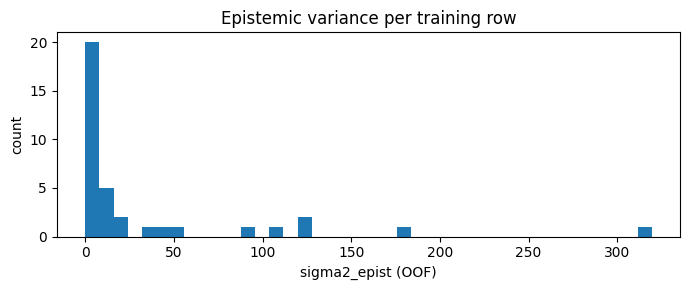

In [25]:
plt.figure(figsize=(7, 3))
plt.hist(sigma2_epist_oof, bins=40)
plt.xlabel("sigma2_epist (OOF)")
plt.ylabel("count")
plt.title("Epistemic variance per training row")
plt.tight_layout()
plt.show()

## Assesment comparing with lin

In [26]:
mu_recomputed_lin, sigma2_epist_oof_lin = modl.compute_mu_and_epistemic_variance(
    preds_matrix=oof_matrix,
    weights=weights,
    use_weights=False,
)

mu_diffs_lin = np.abs(mu_recomputed_lin - mu_oof)
mu_diffs_lin.describe()
# print("sigma2_epist_oof stats:")
# print(f"  mean   = {sigma2_epist_oof_lin.mean():.4f}")
# print(f"  median = {np.median(sigma2_epist_oof_lin):.4f}")
# print(f"  max    = {sigma2_epist_oof_lin.max():.4f}")

count    36.000000
mean      3.764909
std       2.328998
min       0.084167
25%       1.590988
50%       3.812553
75%       5.179028
max      10.867645
Name: tensile_strength_final, dtype: float64

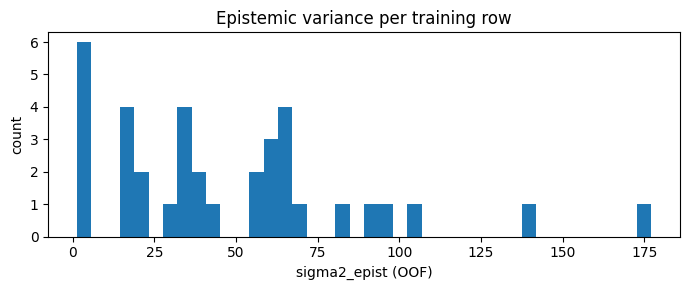

In [27]:
plt.figure(figsize=(7, 3))
plt.hist(sigma2_epist_oof_lin, bins=40)
plt.xlabel("sigma2_epist (OOF)")
plt.ylabel("count")
plt.title("Epistemic variance per training row")
plt.tight_layout()
plt.show()

## Section 5 Conclusion
When number of lines is at least > 40 

Linear shows way more errors between the recomputed values. Weighted one is corrected.

# 6. Build Aleatoric Targets $\tilde r^2$

Each training row gets a noisy point-estimate of the aleatoric variance:

$$\tilde r_i^2 = \max\!\left((y_i - \hat\mu^{\text{OOF}}(\mathbf{x}_i))^2 - \hat\sigma^2_{\text{epist}}(\mathbf{x}_i),\;0\right).$$

Subtracting the epistemic component avoids double-counting it. Truncation at zero handles rows where the ensemble disagreement exceeds the squared residual.

In [28]:
r_tilde_sq, residuals_oof_arr, diag = modl.build_aleatoric_targets(
    y_true=df[TARGET].values,
    mu_oof=mu_oof.values,
    sigma2_epist_oof=sigma2_epist_oof,
)

print("=== Aleatoric target diagnostics ===")
for k, v in diag.items():
    print(f"  {k:20s} = {v}")

=== Aleatoric target diagnostics ===
  n_total              = 36
  n_truncated          = 10
  pct_truncated        = 27.77777777777778
  r_tilde_sq_min       = 0.0
  r_tilde_sq_max       = 4434.599667022604
  r_tilde_sq_mean      = 259.7807028724024
  r_tilde_sq_median    = 8.435257045969722


In [29]:
r_tilde_sq

array([7.65367903e+01, 7.43719589e+00, 1.02494493e+00, 0.00000000e+00,
       0.00000000e+00, 1.11919520e+02, 2.06398780e+01, 9.43331820e+00,
       5.59372923e+00, 1.05331501e-01, 4.82730866e+01, 0.00000000e+00,
       2.79011735e+00, 1.86530213e+01, 0.00000000e+00, 1.43242379e+01,
       1.60593452e+00, 4.52811323e-01, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 2.05800787e+01, 0.00000000e+00, 2.65386329e-01,
       0.00000000e+00, 1.04069664e+02, 1.98981806e+03, 1.10191335e+03,
       8.59462136e+02, 0.00000000e+00, 1.44769047e+01, 1.36580822e+01,
       2.02670254e+02, 4.43459967e+03, 2.57505939e+02, 3.42958728e+01])

# 7. Train Model B — Aleatoric Variance Predictor

Model B is trained on $\log(\tilde r^2 + \epsilon)$ to keep the regression target well-conditioned (variances are non-negative and right-skewed). Inference back-transforms via $\exp$.

In [30]:
predictor_b = modl.fit_model_b(
    df=df,
    features=FEATURES,
    r_tilde_sq=r_tilde_sq,
    path=os.path.join(EXPERIMENT_DIR, "model_b"),
    presets=PRESETS_B,
    num_bag_folds=NUM_BAG_FOLDS_B,
    num_stack_levels=NUM_STACK_LEVELS_B,
    time_limit=TIME_LIMIT_B,
)


Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.11.9
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26200
CPU Count:          8
Pytorch Version:    2.9.1+cpu
CUDA Version:       CUDA is not available
Memory Avail:       5.30 GB / 31.57 GB (16.8%)
Disk Space Avail:   721.91 GB / 932.08 GB (77.5%)
Presets specified: ['medium_quality']
Using hyperparameters preset: hyperparameters='default'
Beginning AutoGluon training ... Time limit = 60s
AutoGluon will save models to "c:\Users\fmfoa\Projects\uncertainty-aware-predictors\models\annealing_tensile_strength\test11082026\model_b"
Train Data Rows:    36
Train Data Columns: 5
Label Column:       log_r_tilde_sq
AutoGluon infers your prediction problem is: 'regression' (because dtype of label-column == float and many unique label-values observed).
	Label info (max, min, mean, stddev): (8.397192624158162, -13.815510557964274, -1.565

In [31]:
predictor_b.leaderboard(silent=True)

,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,WeightedEnsemble_L2,-7.669085,root_mean_squared_error,0.066945,12.998909,0.000999,0.009004,2,True,10
1,CatBoost_BAG_L1,-7.744267,root_mean_squared_error,0.006962,2.054293,0.006962,2.054293,1,True,4
2,NeuralNetTorch_BAG_L1,-7.748956,root_mean_squared_error,0.040305,8.160277,0.040305,8.160277,1,True,8
3,LightGBMLarge_BAG_L1,-7.789207,root_mean_squared_error,0.005524,1.681177,0.005524,1.681177,1,True,9
4,XGBoost_BAG_L1,-7.839686,root_mean_squared_error,0.013155,1.094158,0.013155,1.094158,1,True,7
5,LightGBMXT_BAG_L1,-8.002698,root_mean_squared_error,0.002868,0.981089,0.002868,0.981089,1,True,1
6,LightGBM_BAG_L1,-8.002698,root_mean_squared_error,0.003013,1.339762,0.003013,1.339762,1,True,2
7,NeuralNetFastAI_BAG_L1,-8.162415,root_mean_squared_error,0.044517,6.975233,0.044517,6.975233,1,True,6
8,RandomForestMSE_BAG_L1,-8.660739,root_mean_squared_error,0.056290,0.509757,0.056290,0.509757,1,True,3
9,ExtraTreesMSE_BAG_L1,-8.701705,root_mean_squared_error,0.054681,0.491149,0.054681,0.491149,1,True,5


In [32]:
predictor_b.predict_oof()  

0    -0.460743
1     0.473633
2    -3.448502
3    -0.971442
4    -2.402870
5    -0.798235
6    -1.665478
7    -1.733488
8    -0.973937
9    -0.621043
10   -1.751194
11   -0.972207
12   -1.075583
13   -1.968481
14   -1.189136
15   -0.942331
16   -1.353566
17   -1.622956
18   -1.190536
19   -3.979410
20   -4.388637
21   -3.441845
22   -2.241254
23   -3.274714
24   -1.147082
25   -0.516962
26   -0.504626
27   -0.674349
28   -0.215028
29   -0.555149
30   -0.235869
31   -1.630900
32   -2.274161
33   -1.202546
34   -1.696138
35   -0.415707
Name: log_r_tilde_sq, dtype: float32

In [33]:
df_lado_a_lado = pd.DataFrame({
    "residual_oof": residuals_oof,
    "predict_random_error": predictor_b.predict_oof()  , 
    "epistemic_error": sigma2_epist_oof,
    f"{TARGET}": df[f"{TARGET}"],
    f"{TARGET}_final": df[TARGET]
}) 
df_lado_a_lado

,residual_oof,predict_random_error,epistemic_error,tensile_strength_final,tensile_strength_final_final
0,-9.268473,-0.460743,9.367809,249.783315,249.783315
1,3.326937,0.473633,3.631313,255.008013,255.008013
2,3.148146,-3.448502,8.885877,247.080000,247.080000
3,0.585061,-0.971442,3.002698,242.210000,242.210000
4,-12.900161,-2.402870,183.328829,239.640000,239.640000
5,-10.733000,-0.798235,3.277779,232.030000,232.030000
6,-4.643383,-1.665478,0.921124,236.230000,236.230000
7,-3.083120,-1.733488,0.072311,237.240000,237.240000
8,-2.485615,-0.973937,0.584551,239.410000,239.410000
9,0.372836,-0.621043,0.033675,239.700000,239.700000


# 8. Calibration Diagnostics

Test whether the central α-intervals produced by the predictive Gaussian actually contain the true $y$ on a fraction $\approx \alpha$ of OOF points.

- $\alpha$ here is the **nominal coverage** of an interval (between 0 and 1).
- Empirical coverage **below** nominal ⇒ overconfident (intervals too narrow).
- Empirical coverage **above** nominal ⇒ underconfident (intervals too wide).
- A scalar correction $\hat\sigma \mapsto c \cdot \hat\sigma$ pulls the worst level to nominal; we fit $c$ at $\alpha = 0.9$.

In [34]:
df[TARGET].var()

np.float64(490.6581343258993)

Real coverage considering sigmas calculated so far

Build the predictive distribution. Not totally OOF cause model b is not generating OOF preds, we assume it's optimistic just a bit too small to be considered.


In [35]:
variance_floor = VARIANCE_FLOOR_FRAC * df[TARGET].var()
sigma2_aleat_oof = modl.predict_aleatoric_variance(
    predictor_b, df[FEATURES], variance_floor=variance_floor,
)

sigma2_total_oof = sigma2_epist_oof + sigma2_aleat_oof
sigma_total_oof = np.sqrt(sigma2_total_oof)

y_true = df[TARGET].values
cal_before = modl.calibration_table(
    mu=mu_oof.values, sigma=sigma_total_oof, y_true=y_true,
    alphas=CALIBRATION_ALPHAS,
)
print("=== Calibration BEFORE recalibration ===")
cal_before

=== Calibration BEFORE recalibration ===


,alpha,empirical_coverage,gap
0,0.50,0.250000,-0.250000
1,0.80,0.583333,-0.216667
2,0.90,0.638889,-0.261111
3,0.95,0.750000,-0.200000


Fit a scalar recalibration factor to pull coverage using α=0.9 as nominal reference


In [36]:
c_opt = modl.fit_recalibration_scalar(
    mu=mu_oof.values,
    sigma=sigma_total_oof,
    y_true=y_true,
    target_alpha=RECALIBRATION_TARGET_ALPHA,
)
print(f"Recalibration scalar c = {c_opt:.4f}")

cal_after = modl.calibration_table(
    mu=mu_oof.values, sigma=c_opt * sigma_total_oof, y_true=y_true,
    alphas=CALIBRATION_ALPHAS,
)
print("\n=== Calibration AFTER recalibration ===")
cal_after

Recalibration scalar c = 2.3976

=== Calibration AFTER recalibration ===


,alpha,empirical_coverage,gap
0,0.50,0.638889,0.138889
1,0.80,0.777778,-0.022222
2,0.90,0.861111,-0.038889
3,0.95,0.916667,-0.033333


# 8.1 Validation Set Evaluation

Evaluate the freshly trained pair (A + B, with the recalibration $c$) on a
validation DataFrame.

`modl.predict_target` is target-agnostic: it accepts a DataFrame **or a dict**
and any AutoGluon predictor (IACS, UTS, Model B...), inferring the features
from the predictor when not given.

In [37]:
c_opt
weights

array([1.62846605e-08, 0.00000000e+00, 0.00000000e+00, 5.67681150e-08,
       0.00000000e+00, 5.55684209e-08, 0.00000000e+00, 4.44444355e-01,
       5.55555516e-01])

In [38]:
len(base_model_names)
len(weights)

9

In [39]:
# ---- Validation set: df_schema (illustrative; in-sample, see caveat) ----
# df_val = df_schema.copy()

# Full calibrated predictive distribution on the validation set.
preds_val = modl.predict_with_uncertainty(
    X=df.copy(), # df_schema.copy()
    predictor_a=predictor_a,
    predictor_b=predictor_b,
    weights=weights,
    model_names=base_model_names,
    features=FEATURES,
    variance_floor=variance_floor,
    recalibration_c=c_opt,
    use_weights=USE_WEIGHTED_VARIANCE,
    y_max=Y_MAX,
)

val_metrics = evla.metrics_on_dataframe(
    df=df.copy(), #df_schema.copy()
    target=TARGET,
    mu=preds_val["mu"].to_numpy(),
    sigma=preds_val["sigma_total"].to_numpy(),
    alphas=CALIBRATION_ALPHAS,
)
print("=== Validation metrics (df_schema) ===")
print({k: round(v, 4) for k, v in val_metrics.items() if k != "coverage"})
print("coverage:", {a: round(c, 3) for a, c in val_metrics["coverage"].items()})

=== Validation metrics (df_schema) ===
{'rmse': 12.3351, 'mae': 7.5572, 'mape': 2.7932, 'r2': 0.681}
coverage: {0.5: 0.833, 0.8: 0.944, 0.9: 0.972, 0.95: 0.972}


In [40]:
# # ---- Target-agnostic point prediction from a plain dict ----
# single = modl.predict_target(
#     predictor_a,
#     {"initial_diameter": 1.5, "purity": 99.9, "iacs": 88.26, "temperature": 623.0, "time": 60.0},
# )
# print(f"Predicted {TARGET}: {single[0]:.3f}")

# 9. Inference Example

Use the packaged `predict_with_uncertainty` to apply both models to new rows and return a full predictive distribution. The `recalibration_c` argument scales $\hat\sigma$ to match the calibration above.

In [41]:
df.head(5)

,initial_diameter,tensile_strength,purity,temperature,time,tensile_strength_final
0,2.160000,391.690000,99.9,573.0,30.0,249.783315
1,2.182333,387.595254,99.9,573.0,30.0,255.008013
2,1.200000,431.580000,99.9,523.0,30.0,247.080000
3,1.200000,431.580000,99.9,523.0,60.0,242.210000
4,1.200000,431.580000,99.9,523.0,90.0,239.640000


In [42]:
# Fit the OOD reference on the training inputs (stored in artifacts later).
ood_ref = modl.fit_ood_reference(df, features=FEATURES)

preds = modl.predict_with_uncertainty(
    X=df.head(5),
    predictor_a=predictor_a,
    predictor_b=predictor_b,
    weights=weights,
    model_names=base_model_names,
    features=FEATURES,
    variance_floor=variance_floor,
    recalibration_c=c_opt,
    use_weights=USE_WEIGHTED_VARIANCE,
    y_max=Y_MAX,          # physical ceiling -> mu_trunc / sigma_trunc / p_above_max
    ood_ref=ood_ref,      # inputs outside training cloud get inflated sigma
)
preds


,mu,sigma2_epist,sigma2_aleat,sigma2_total,sigma_total,leader_model_prediction,ood_multiplier,mu_trunc,sigma_trunc,p_above_max
0,256.266991,0.919344,4.906581,33.491091,5.787149,256.266998,1.0,104.779240,0.220441,1.0
1,255.169813,0.138810,4.906581,29.004090,5.385545,255.169815,1.0,104.807352,0.192403,1.0
2,248.249549,3.146450,4.906581,46.293903,6.803962,248.249542,1.0,104.678272,0.321015,1.0
3,245.178050,10.956085,4.906581,91.188603,9.549272,245.178055,1.0,104.355382,0.641738,1.0
4,244.029184,9.054957,4.906581,80.259725,8.958779,244.029190,1.0,104.427411,0.570292,1.0


# 10. Persist Artifacts

Save everything that the downstream stages (controller, propagation) will need.

In [43]:
# ---- Experiment artifacts (everything under EXPERIMENT_DIR / TAG) ----
artifacts_path = os.path.join(EXPERIMENT_DIR, "artifacts.pkl")

artifacts = {
    "features": FEATURES,
    "target": TARGET,
    "base_model_names": base_model_names,
    "weights": weights,
    "variance_floor": variance_floor,
    "recalibration_c": c_opt,
    "use_weighted_variance": USE_WEIGHTED_VARIANCE,
    "calibration_before": cal_before,
    "calibration_after": cal_after,
    "y_max": Y_MAX,
    "ood_ref": ood_ref,
}
with open(artifacts_path, "wb") as f:
    pickle.dump(artifacts, f)

print(f"Saved to: {artifacts_path}")


Saved to: ../../models/annealing_tensile_strength\test11082026\artifacts.pkl


In [44]:
# ---- Save global configuration (1.1) as YAML for this experiment (TAG) ----
global_config = {
    "TAG": TAG,
    "SCHEMA_DATE": SCHEMA_DATE,
    "varv.PATHS.data_raw": varv.PATHS.data_raw,
    "varv.PATHS.models": varv.PATHS.models,
    "FILE_NAME": FILE_NAME,
    "FILE_NAME_SCHEMA_DATA": FILE_NAME_SCHEMA_DATA,
    "PROCESS": PROCESS,
    "TARGET": TARGET,
    "FEATURES": FEATURES,
    "WEIGHT_ON_ESSAY_ROWS": WEIGHT_ON_ESSAY_ROWS,
    "PRESETS_A": PRESETS_A,
    "NUM_BAG_FOLDS_A": NUM_BAG_FOLDS_A,
    "NUM_BAG_SETS_A": NUM_BAG_SETS_A,
    "NUM_STACK_LEVELS_A": NUM_STACK_LEVELS_A,
    "TIME_LIMIT_A": TIME_LIMIT_A,
    "PRESETS_B": PRESETS_B,
    "NUM_BAG_FOLDS_B": NUM_BAG_FOLDS_B,
    "NUM_STACK_LEVELS_B": NUM_STACK_LEVELS_B,
    "TIME_LIMIT_B": TIME_LIMIT_B,
    "USE_WEIGHTED_VARIANCE": USE_WEIGHTED_VARIANCE,
    "VARIANCE_FLOOR_FRAC": VARIANCE_FLOOR_FRAC,
    "CALIBRATION_ALPHAS": list(CALIBRATION_ALPHAS),
    "RECALIBRATION_TARGET_ALPHA": RECALIBRATION_TARGET_ALPHA,
    "USE_SHARED_FOLDS": USE_SHARED_FOLDS,
    "FOLD_SEED": FOLD_SEED,
    "Y_MAX": Y_MAX,
}

config_path = os.path.join(EXPERIMENT_DIR, "global_config.txt")
with open(config_path, "w") as f:
    yaml.dump(global_config, f, default_flow_style=False, sort_keys=False)

print(f"Saved to: {config_path}")


Saved to: ../../models/annealing_tensile_strength\test11082026\global_config.txt


In [45]:
# ---- OOF metrics: AutoGluon (Model A leader) vs H2O AutoML leader ----
# Both vectors are out-of-fold predictions; metrics are UNWEIGHTED on both
# sides, and with USE_SHARED_FOLDS=True the folds are identical -> coherent.
h2o_oof_preds = (
    aml_h2o.leader.cross_validation_holdout_predictions()
    .as_data_frame()
    .iloc[:, 0]
    .to_numpy()
)

metrics_agl = evla.one_step_metrics(y_true=y_true, mu=mu_oof.values)
metrics_h2o = evla.one_step_metrics(y_true=y_true, mu=h2o_oof_preds)

metrics_df = pd.DataFrame(
    [
        {"model": "AutoGluon (Model A, leader)", **metrics_agl},
        {"model": "H2O AutoML (leader)", **metrics_h2o},
    ]
)[["model", "rmse", "mae", "mape", "r2"]]

print(metrics_df)

# ---- Leaderboards from both engines ----
leaderboard_agl = predictor_a.leaderboard(silent=True)
leaderboard_h2o = aml_h2o.leaderboard.as_data_frame()

# ---- Save everything for this experiment (TAG) into separate CSV files ----
metrics_df.to_csv(os.path.join(EXPERIMENT_DIR, "metrics_comparison.csv"), index=False)
leaderboard_agl.to_csv(os.path.join(EXPERIMENT_DIR, "leaderboard_autogluon.csv"), index=False)
leaderboard_h2o.to_csv(os.path.join(EXPERIMENT_DIR, "leaderboard_h2o.csv"), index=False)

print(f"Saved to: {EXPERIMENT_DIR}")


c:\Users\fmfoa\Projects\uncertainty-aware-predictors\.venv\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


                         model       rmse       mae      mape        r2
0  AutoGluon (Model A, leader)  16.810625  9.656452  3.514243  0.407589
1          H2O AutoML (leader)  16.327266  6.790561  2.409874  0.441167


c:\Users\fmfoa\Projects\uncertainty-aware-predictors\.venv\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


Saved to: ../../models/annealing_tensile_strength\test11082026


# 11. Load Artifacts & Predict (deployment simulation)

This section simulates a fresh process: it loads ONLY what was persisted in
Section 10 (`artifacts.pkl`) plus the two AutoGluon predictors from disk —
no variable from the training session above is reused. This is exactly what a
deployment script (or the MBC controller) would do. The same
`predict_with_uncertainty` call as Section 9 runs, but every ingredient
(`weights`, `recalibration_c`, `ood_ref`, `y_max`, ...) comes from the
reloaded artifacts, proving the persisted bundle is self-contained.

In [46]:

# ---- 1) Load the persisted artifact bundle (Section 10) ----
loaded_artifacts = load.load_pickle(EXPERIMENT_DIR, "artifacts.pkl")

# ---- 2) Reload both AutoGluon predictors from their TAG subfolders ----
predictor_a_loaded = TabularPredictor.load(
    os.path.join(EXPERIMENT_DIR, "model_a")
)
predictor_b_loaded = TabularPredictor.load(
    os.path.join(EXPERIMENT_DIR, "model_b")
)

print("Loaded artifacts keys:", list(loaded_artifacts.keys()))
print("Target:", loaded_artifacts["target"])
print("Features:", loaded_artifacts["features"])

Loaded artifacts keys: ['features', 'target', 'base_model_names', 'weights', 'variance_floor', 'recalibration_c', 'use_weighted_variance', 'calibration_before', 'calibration_after', 'y_max', 'ood_ref']
Target: tensile_strength_final
Features: ['initial_diameter', 'tensile_strength', 'purity', 'temperature', 'time']


In [47]:
# ---- 3) Predict using ONLY the reloaded objects ----
# Build a small query frame (here: first rows of df, but in deployment this
# would be a brand-new candidate route from the controller).
X_query = df.head(5)

preds_loaded = modl.predict_with_uncertainty(
    X=X_query,
    predictor_a=predictor_a_loaded,
    predictor_b=predictor_b_loaded,
    weights=loaded_artifacts["weights"],
    model_names=loaded_artifacts["base_model_names"],
    features=loaded_artifacts["features"],
    variance_floor=loaded_artifacts["variance_floor"],
    recalibration_c=loaded_artifacts["recalibration_c"],
    use_weights=loaded_artifacts["use_weighted_variance"],
    y_max=loaded_artifacts["y_max"],
    ood_ref=loaded_artifacts["ood_ref"],
)
preds_loaded

,mu,sigma2_epist,sigma2_aleat,sigma2_total,sigma_total,leader_model_prediction,ood_multiplier,mu_trunc,sigma_trunc,p_above_max
0,256.266991,0.919344,4.906581,33.491091,5.787149,256.266998,1.0,104.779240,0.220441,1.0
1,255.169813,0.138810,4.906581,29.004090,5.385545,255.169815,1.0,104.807352,0.192403,1.0
2,248.249549,3.146450,4.906581,46.293903,6.803962,248.249542,1.0,104.678272,0.321015,1.0
3,245.178050,10.956085,4.906581,91.188603,9.549272,245.178055,1.0,104.355382,0.641738,1.0
4,244.029184,9.054957,4.906581,80.259725,8.958779,244.029190,1.0,104.427411,0.570292,1.0


In [48]:
# # ---- 4) Target-agnostic quick prediction from a plain dict ----
# # Works for any predictor/target via modl.predict_target (features inferred
# # from the predictor when not passed explicitly).
# single_loaded = modl.predict_target(
#     predictor_a_loaded,
#     {"initial_diameter": 1.5, "purity": 99.9, "iacs": 88.26, "temperature": 623.0, "time": 60.0},
#     features=loaded_artifacts["features"],
# )
# print(f"Predicted {loaded_artifacts['target']}: {single_loaded[0]:.3f}")

In [49]:
# ---- 5) Sanity check: reloaded predictions match the in-session ones ----
# (Section 9 computed `preds` on df.head(5) with the same ood_ref/c_opt.)
import numpy as np
if "preds" in dir():
    max_mu_diff = float(np.abs(preds["mu"].to_numpy()
                               - preds_loaded["mu"].to_numpy()).max())
    max_sigma_diff = float(np.abs(preds["sigma_total"].to_numpy()
                                  - preds_loaded["sigma_total"].to_numpy()).max())
    print(f"max |mu diff|    = {max_mu_diff:.2e}")
    print(f"max |sigma diff| = {max_sigma_diff:.2e}")
    print("OK: artifacts reproduce the in-session pipeline."
          if max(max_mu_diff, max_sigma_diff) < 1e-8
          else "WARNING: mismatch - check that Section 9 used the same ood_ref.")
else:
    print("Run Section 9 first to enable the sanity check.")

max |mu diff|    = 0.00e+00
max |sigma diff| = 0.00e+00
OK: artifacts reproduce the in-session pipeline.
